# KNN Comparison:


- **Section 1:**  KNN workflow using Lasso-based feature selection and comparison models
- **Section 2:**  KNN workflow using a manually shortened feature list (60 selected features)
- **Section 3:** Final comparison and recommendation

These models applies **K-Nearest Neighbors (KNN) regression** to predict **average Airbnb price**.  
KNN is a distance-based supervised learning method that predicts a numeric value by averaging the target values of the **most similar observations** in the training set.

KNN is appropriate for this project because Airbnb pricing is naturally **similarity-based**. If two listings are similar in terms of location, amenities, host characteristics, room type, availability, and review patterns, then their prices are also likely to be similar. This makes KNN a reasonable model for predicting listing price.

---

## Section 1: Lasso & Scaled KNN Approach

The section below presents the original Lasso-based KNN workflow and results used for comparison in this notebook.


## KNN Models

Below are the KNN models used to predict Airbnb nightly price in this project.

##### Model 1: No Scaling (69 features)
- Basic Train/Test  
- Cross Validation  

##### Model 2: Scaled Features (69 features)
- Basic Train/Test  
- Cross Validation  

##### Model 3: Lasso (α = 1.0)
- Basic Train/Test (**31 features removed**)  
- Cross Validation (**31 features removed**)  

##### Model 4: Lasso (α = 0.035)
- Basic Train/Test (**17 features removed**)  
- Cross Validation (**17 features removed**)  

### Why Lasso was used in Models 3 and 4

Lasso was used in Models 3 and 4 as a practical **feature reduction method** to improve KNN performance. Since KNN is a **distance-based model**, it can perform poorly when too many weak or irrelevant features are included, especially in higher-dimensional datasets.

Although Lasso is based on a **linear modeling framework**, and KNN is a **non-parametric distance-based method**, Lasso still provides a useful and data-driven way to remove less important predictors. This made it a more defensible feature selection approach than relying only on manual choices or arbitrary cutoffs.

As shown later in the results, using Lasso-based feature selection led to a **substantial reduction in prediction error**, particularly in MSE. This suggests that even though Lasso and KNN are based on different modeling assumptions, Lasso was still effective as a **pragmatic data engineering step** for improving KNN performance.

### Why 5-fold cross-validation was used

For all cross-validation models, **5-fold cross-validation** was used to keep the evaluation process consistent across all model versions.

Since the main comparison in this section focuses on how **scaling and feature selection** affect KNN performance, keeping the number of folds constant helps isolate those differences more clearly.

Using more folds, such as **8-fold or 10-fold cross-validation**, could also be explored in future work to see whether it changes the stability or average accuracy of the models. However, 5-fold cross-validation provides a strong and commonly used balance between **computational efficiency** and **reliable performance estimation**.

---
### Model 1: No Scaling (Basic Train Test)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

df = pd.read_csv('Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv')
df.head()

X = df.drop('rate_avg', axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

neighbors_settings = [3, 4, 5, 7, 9, 11]

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test - y_pred))                   
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) 

    records.append((n_neighbors, round(r2, 4), round(mse, 2), round(rmse, 4),round(mae, 2), round(mape, 2)))
    preds[n_neighbors] = y_pred

results_df = pd.DataFrame(records, columns=["k", "R²", "MSE", "RMSE","MAE", "MAPE"]).set_index("k")
print(f"\nModel 1 — All Features, No Scaling")
print(f"\n{'k':<6} {'R²':<10} {'MSE':<12} {'RMSE':<10} {'MAE':<10} {'MAPE':<10}")                    
print("-" * 58)                                                                                          
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['R²']:<10} {row['MSE']:<12} {row['RMSE']:<10} {row['MAE']:<10} {row['MAPE']:<10}")


(2580, 70) (645, 70) (2580,) (645,)

Model 1 — All Features, No Scaling

k      R²         MSE          RMSE       MAE        MAPE      
----------------------------------------------------------
3      0.1928     8589.2       92.6779    58.53      0.53      
4      0.2165     8337.09      91.3076    58.16      0.53      
5      0.2214     8285.36      91.024     58.48      0.53      
7      0.2235     8263.2       90.9022    57.13      0.52      
9      0.2484     7997.8       89.4304    55.99      0.52      
11     0.248      8001.59      89.4516    55.91      0.52      


### Model 1: No Scaling (Cross Validation)

(2580, 70) (645, 70) (2580,) (645,)

Model 1 — All Features, No Scaling CV

k      CV R²      CV MSE       CV RMSE      CV MAE       CV MAPE   
--------------------------------------------------------------
3      0.2698     8615.61      92.8203      58.28        0.5372    
4      0.2701     8618.7       92.837       57.95        0.5375    
5      0.2521     8830.14      93.9688      58.04        0.5429    
7      0.2253     9148.49      95.6477      58.28        0.5488    
9      0.2325     9067.29      95.2223      57.62        0.5399    
11     0.2259     9143.67      95.6225      57.7         0.5402    


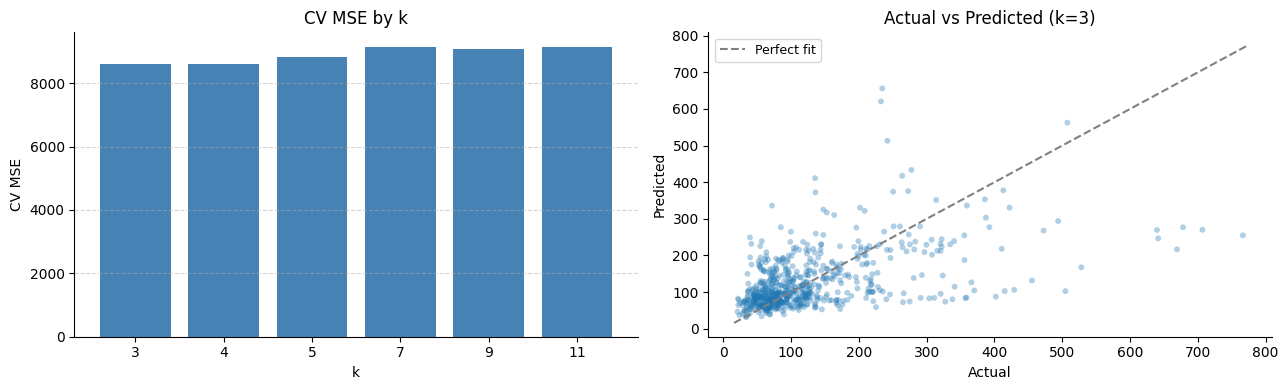

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.neighbors import KNeighborsRegressor

df = pd.read_csv('Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv')
df.head()

X = df.drop('rate_avg', axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

neighbors_settings = [3, 4, 5, 7, 9, 11]

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)

    cv_results = cross_validate(knn, X_train, y_train, cv=5, scoring={
        'mse':  'neg_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'mape': 'neg_mean_absolute_percentage_error',
        'r2':   'r2'
    })
    cv_mse  = -cv_results['test_mse'].mean()
    cv_rmse = np.sqrt(cv_mse)
    cv_mae  = -cv_results['test_mae'].mean()
    cv_mape = -cv_results['test_mape'].mean()
    cv_r2   = cv_results['test_r2'].mean()

    records.append((n_neighbors, round(cv_r2, 4), round(cv_mse, 2), round(cv_rmse, 4), round(cv_mae, 2), round(cv_mape, 4)))
    preds[n_neighbors] = knn.fit(X_train, y_train).predict(X_test)

results_df = pd.DataFrame(records, columns=["k", "CV R²", "CV MSE", "CV RMSE", "CV MAE", "CV MAPE"]).set_index("k")
print(f"\nModel 1 — All Features, No Scaling CV")
print(f"\n{'k':<6} {'CV R²':<10} {'CV MSE':<12} {'CV RMSE':<12} {'CV MAE':<12} {'CV MAPE':<10}")
print("-" * 62)
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['CV R²']:<10} {row['CV MSE']:<12} {row['CV RMSE']:<12} {row['CV MAE']:<12} {row['CV MAPE']:<10}")

best_k = results_df["CV MSE"].idxmin()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.bar([str(k) for k in results_df.index], results_df["CV MSE"], color="steelblue")
ax1.set_xlabel("k"); ax1.set_ylabel("CV MSE"); ax1.set_title("CV MSE by k")
ax1.grid(axis="y", linestyle="--", alpha=0.5); sns.despine(ax=ax1)
lims = [y_test.min() - 5, y_test.max() + 5]
ax2.plot(lims, lims, "--", color="gray", lw=1.5, label="Perfect fit")
ax2.scatter(y_test, preds[best_k], alpha=0.35, s=18, edgecolors="none")
ax2.set_xlabel("Actual"); ax2.set_ylabel("Predicted")
ax2.set_title(f"Actual vs Predicted (k={best_k})"); ax2.legend(fontsize=9)
sns.despine(ax=ax2); plt.tight_layout(); plt.show()

---
### Model 2: Scaled Features (Basic Train Test)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv')
df.head()

X = df.drop('rate_avg', axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

neighbors_settings = [3, 4, 5, 7, 9, 11]

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test - y_pred))                        
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) 

    records.append((n_neighbors, round(r2, 4), round(mse, 2), round(rmse, 4), round(mae, 2), round(mape, 2)))
    preds[n_neighbors] = y_pred

results_df = pd.DataFrame(records, columns=["k", "R²", "MSE", "RMSE","MAE", "MAPE"]).set_index("k")
print(f"\nModel 2 — All Features, Scaled")
print(f"\n{'k':<6} {'R²':<10} {'MSE':<12} {'RMSE':<10} {'MAE':<10} {'MAPE':<10}")                    
print("-" * 58)                                                                                          
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['R²']:<10} {row['MSE']:<12} {row['RMSE']:<10} {row['MAE']:<10} {row['MAPE']:<10}")

(2580, 70) (645, 70) (2580,) (645,)

Model 2 — All Features, Scaled

k      R²         MSE          RMSE       MAE        MAPE      
----------------------------------------------------------
3      0.6216     4026.63      63.4557    40.99      0.36      
4      0.6654     3560.9       59.6733    39.89      0.36      
5      0.6786     3420.04      58.4811    39.33      0.36      
7      0.7022     3168.88      56.2928    38.03      0.35      
9      0.7157     3024.93      54.9994    37.24      0.35      
11     0.7201     2978.95      54.5798    37.64      0.35      


### Model 2: Scaled Features (Cross Validation)

(2580, 70) (645, 70) (2580,) (645,)



Model 2 CV — All Features, With Scaling

k      CV R²      CV MSE       CV RMSE      CV MAE       CV MAPE   
--------------------------------------------------------------
3      0.6639     3968.76      62.9981      41.06        0.3784    
4      0.6748     3843.61      61.9968      40.91        0.3776    
5      0.6833     3743.06      61.1805      40.44        0.3741    
7      0.7031     3513.41      59.274       39.19        0.3659    
9      0.7114     3415.15      58.4393      38.71        0.3627    
11     0.7045     3495.55      59.1232      39.47        0.3688    


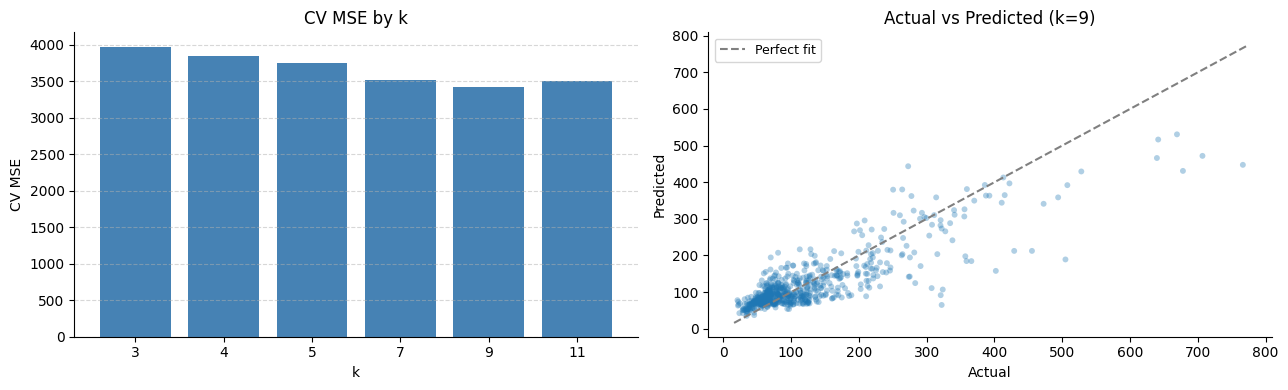

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv')
df.head()

X = df.drop('rate_avg', axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

neighbors_settings = [3, 4, 5, 7, 9, 11]

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)

    cv_results = cross_validate(knn, X_train_scaled, y_train, cv=5, scoring={
        'r2':   'r2',
        'mse':  'neg_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'mape': 'neg_mean_absolute_percentage_error'
    })
    cv_r2   =  cv_results['test_r2'].mean()
    cv_mse  = -cv_results['test_mse'].mean()
    cv_rmse = np.sqrt(cv_mse)
    cv_mae  = -cv_results['test_mae'].mean()
    cv_mape = -cv_results['test_mape'].mean()

    records.append((n_neighbors, round(cv_r2, 4), round(cv_mse, 2), round(cv_rmse, 4), round(cv_mae, 2), round(cv_mape, 4)))
    preds[n_neighbors] = knn.fit(X_train_scaled, y_train).predict(X_test_scaled)

results_df = pd.DataFrame(records, columns=["k", "CV R²", "CV MSE", "CV RMSE", "CV MAE", "CV MAPE"]).set_index("k")
print(f"\nModel 2 CV — All Features, With Scaling")
print(f"\n{'k':<6} {'CV R²':<10} {'CV MSE':<12} {'CV RMSE':<12} {'CV MAE':<12} {'CV MAPE':<10}")
print("-" * 62)
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['CV R²']:<10} {row['CV MSE']:<12} {row['CV RMSE']:<12} {row['CV MAE']:<12} {row['CV MAPE']:<10}")

best_k = results_df["CV MSE"].idxmin()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.bar([str(k) for k in results_df.index], results_df["CV MSE"], color="steelblue")
ax1.set_xlabel("k"); ax1.set_ylabel("CV MSE"); ax1.set_title("CV MSE by k")
ax1.grid(axis="y", linestyle="--", alpha=0.5); sns.despine(ax=ax1)
lims = [y_test.min() - 5, y_test.max() + 5]
ax2.plot(lims, lims, "--", color="gray", lw=1.5, label="Perfect fit")
ax2.scatter(y_test, preds[best_k], alpha=0.35, s=18, edgecolors="none")
ax2.set_xlabel("Actual"); ax2.set_ylabel("Predicted")
ax2.set_title(f"Actual vs Predicted (k={best_k})"); ax2.legend(fontsize=9)
sns.despine(ax=ax2); plt.tight_layout(); plt.show()

---
### Model 3: Lasso (α = 1.0) (Basic Train Test)

Below is the initial calculation to retrieve the features to remove and fine tune the KNN model with Lasso when alpha = 1. 

In [5]:
import numpy as np
import pandas as pd
 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
 
df = pd.read_csv('Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv')
df.head()
 
X = df.drop('rate_avg', axis=1)
y = df['rate_avg']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
 
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
 
# Scaling features ( Since Lasso penalizes coefficients, features must be on same scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
# Building and training the model
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, y_train)
 
# Making predictions on the test set
y_pred = lasso.predict(X_test_scaled)
 
# Identify which features were zeroed out by Lasso
coef_df = pd.DataFrame({'feature': X.columns, 'coefficient': lasso.coef_})
 
zeroed_features = coef_df[coef_df['coefficient'] == 0]
kept_features = coef_df[coef_df['coefficient'] != 0]
 
print(f"\nTotal features: {len(X.columns)}")
print(f"Features zeroed out by Lasso: {len(zeroed_features)}")
print(f"Features kept by Lasso: {len(kept_features)}")
 
print(f"\nZeroed out features:")
print(zeroed_features['feature'].tolist())


(2580, 70) (645, 70) (2580,) (645,)

Total features: 70
Features zeroed out by Lasso: 31
Features kept by Lasso: 39

Zeroed out features:
['rating_overall', 'rating_accuracy', 'rating_checkin', 'rating_cleanliness', 'rating_communication', 'rating_value', 'Hotel_Occupancy_Percentage', 'Average_Daily_Rate', 'Revenue_Per_Available_Room', 'is_winter', 'is_spring', 'is_fall', 'num_public_holidays', 'num_major_events', 'month', 'is_april', 'is_august', 'is_february', 'is_july', 'is_june', 'is_may', 'is_november', 'is_october', 'has_gym', 'listing_type_Entire house', 'listing_type_Private room in bungalow', 'listing_type_Private room in cottage', 'listing_type_Private room in home', 'listing_type_Private room in loft', 'room_type_private_room', 'cancellation_policy_Super Strict 30 Days']


The features found above are now going to be removed from the initial data set, and tested below for both basic train test as well as cross validation.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

df = pd.read_csv('Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv')
df.head()

X = df.drop(['rate_avg', 'rating_overall', 'rating_accuracy', 'rating_checkin',
             'rating_cleanliness', 'rating_communication', 'rating_value',
             'Hotel_Occupancy_Percentage', 'Average_Daily_Rate', 'Revenue_Per_Available_Room',
             'is_winter', 'is_spring', 'is_fall', 'num_public_holidays', 'num_major_events',
             'month', 'is_april', 'is_august', 'is_february', 'is_july', 'is_june', 'is_may',
             'is_november', 'is_october', 'has_gym', 'listing_type_Entire house',
             'listing_type_Private room in bungalow', 'listing_type_Private room in cottage',
             'listing_type_Private room in home', 'listing_type_Private room in loft',
             'room_type_private_room', 'cancellation_policy_Super Strict 30 Days'], axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

neighbors_settings = [3, 4, 5, 7, 9, 11]

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test - y_pred))                         
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) 

    records.append((n_neighbors, round(r2, 4), round(mse, 2), round(rmse, 4), round(mae, 2), round(mape, 2)))
    preds[n_neighbors] = y_pred

results_df = pd.DataFrame(records, columns=["k", "R²", "MSE", "RMSE", "MAE", "MAPE"]).set_index("k")
print(f"\nModel 3 — Lasso (α=1.0) Feature Selection (39 features)")
print(f"\n{'k':<6} {'R²':<10} {'MSE':<12} {'RMSE':<10} {'MAE':<10} {'MAPE':<10}")                    
print("-" * 58)                                                                                          
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['R²']:<10} {row['MSE']:<12} {row['RMSE']:<10} {row['MAE']:<10} {row['MAPE']:<10}")


(2580, 39) (645, 39) (2580,) (645,)

Model 3 — Lasso (α=1.0) Feature Selection (39 features)

k      R²         MSE          RMSE       MAE        MAPE      
----------------------------------------------------------
3      0.8888     1183.45      34.4012    20.01      0.17      
4      0.8995     1069.31      32.7003    19.87      0.17      
5      0.8925     1144.28      33.8272    20.94      0.18      
7      0.866      1425.46      37.7553    23.98      0.2       
9      0.8485     1612.16      40.1517    25.32      0.22      
11     0.8256     1856.23      43.084     27.63      0.24      


### Model 3: Lasso (α = 1.0) (Cross Validation)

(2580, 39) (645, 39) (2580,) (645,)

Model 3 — Lasso (α=1.0) Feature Selection (39 features)

k      CV R²      CV MSE       CV RMSE      CV MAE       CV MAPE   
--------------------------------------------------------------
3      0.8957     1230.98      35.0853      20.76        0.1846    
4      0.8905     1291.34      35.9353      22.16        0.1985    
5      0.8847     1360.64      36.8868      23.18        0.2093    
7      0.8656     1589.09      39.8634      25.74        0.2366    
9      0.8492     1783.25      42.2286      27.53        0.2551    
11     0.833      1974.36      44.4338      29.33        0.2724    


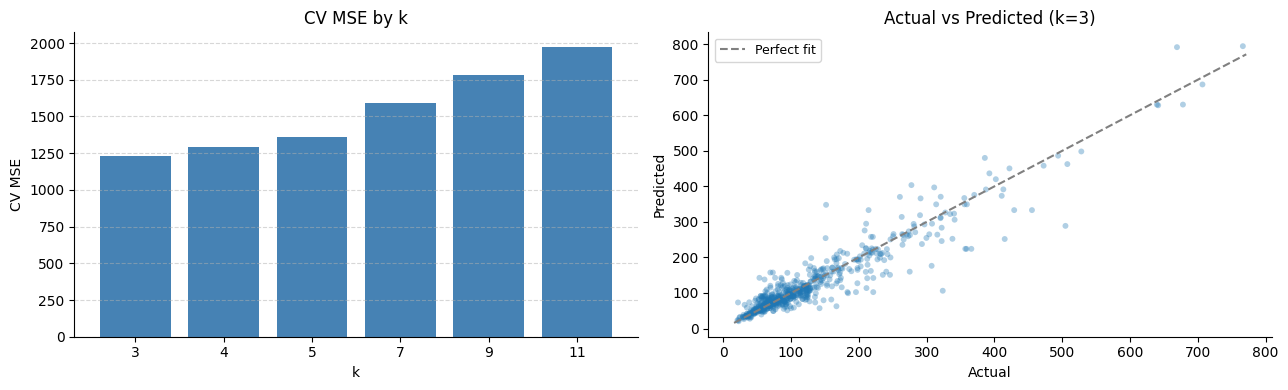

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv')
df.head()

X = df.drop(['rate_avg', 'rating_overall', 'rating_accuracy', 'rating_checkin',
             'rating_cleanliness', 'rating_communication', 'rating_value',
             'Hotel_Occupancy_Percentage', 'Average_Daily_Rate', 'Revenue_Per_Available_Room',
             'is_winter', 'is_spring', 'is_fall', 'num_public_holidays', 'num_major_events',
             'month', 'is_april', 'is_august', 'is_february', 'is_july', 'is_june', 'is_may',
             'is_november', 'is_october', 'has_gym', 'listing_type_Entire house',
             'listing_type_Private room in bungalow', 'listing_type_Private room in cottage',
             'listing_type_Private room in home', 'listing_type_Private room in loft',
             'room_type_private_room', 'cancellation_policy_Super Strict 30 Days'], axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

neighbors_settings = [3, 4, 5, 7, 9, 11]

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)

    cv_results = cross_validate(knn, X_train_scaled, y_train, cv=5, scoring={
        'mse':  'neg_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'mape': 'neg_mean_absolute_percentage_error',
        'r2':   'r2'
    })
    cv_mse  = -cv_results['test_mse'].mean()
    cv_rmse = np.sqrt(cv_mse)
    cv_mae  = -cv_results['test_mae'].mean()
    cv_mape = -cv_results['test_mape'].mean()
    cv_r2   = cv_results['test_r2'].mean()

    records.append((n_neighbors, round(cv_r2, 4), round(cv_mse, 2), round(cv_rmse, 4), round(cv_mae, 2), round(cv_mape, 4)))
    preds[n_neighbors] = knn.fit(X_train_scaled, y_train).predict(X_test_scaled)

results_df = pd.DataFrame(records, columns=["k", "CV R²", "CV MSE", "CV RMSE", "CV MAE", "CV MAPE"]).set_index("k")
print(f"\nModel 3 — Lasso (α=1.0) Feature Selection (39 features)")
print(f"\n{'k':<6} {'CV R²':<10} {'CV MSE':<12} {'CV RMSE':<12} {'CV MAE':<12} {'CV MAPE':<10}")
print("-" * 62)
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['CV R²']:<10} {row['CV MSE']:<12} {row['CV RMSE']:<12} {row['CV MAE']:<12} {row['CV MAPE']:<10}")

best_k = results_df["CV MSE"].idxmin()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.bar([str(k) for k in results_df.index], results_df["CV MSE"], color="steelblue")
ax1.set_xlabel("k"); ax1.set_ylabel("CV MSE"); ax1.set_title("CV MSE by k")
ax1.grid(axis="y", linestyle="--", alpha=0.5); sns.despine(ax=ax1)
lims = [y_test.min() - 5, y_test.max() + 5]
ax2.plot(lims, lims, "--", color="gray", lw=1.5, label="Perfect fit")
ax2.scatter(y_test, preds[best_k], alpha=0.35, s=18, edgecolors="none")
ax2.set_xlabel("Actual"); ax2.set_ylabel("Predicted")
ax2.set_title(f"Actual vs Predicted (k={best_k})"); ax2.legend(fontsize=9)
sns.despine(ax=ax2); plt.tight_layout(); plt.show()

---
### Model 4: Lasso (α = 0.035) (Basic Train Test)

This optimal alpha of 0.035 for our dataset, and the subsequent features to be removed by Lasso are referenced from the findings of the regression model and used here for reasonable feature removal, since KNN for regression is better suited for a reduced amount of features. 

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

df = pd.read_csv('Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv')
df.head()

X = df.drop(['rate_avg', 'Hotel_Occupancy_Percentage', 'Revenue_Per_Available_Room',
             'is_winter', 'is_spring', 'is_summer', 'is_fall', 'num_public_holidays',
             'non_resident_visitors', 'is_august', 'is_february', 'is_july', 'is_june',
             'is_november', 'is_september', 'listing_type_Private room in bungalow',
             'listing_type_Private room in home', 'listing_type_Private room in loft'], axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

neighbors_settings = [3, 4, 5, 7, 9, 11]

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test - y_pred))                          
    mape = np.mean(np.abs((y_test - y_pred) / y_test))

    records.append((n_neighbors, round(r2, 4), round(mse, 2), round(rmse, 4),round(mae, 2), round(mape, 2)))
    preds[n_neighbors] = y_pred

results_df = pd.DataFrame(records, columns=["k", "R²", "MSE", "RMSE", "MAE", "MAPE"]).set_index("k")
print(f"\nModel 4 — Optimal Lasso (α=0.035) Feature Selection (53 features)")
print(f"\n{'k':<6} {'R²':<10} {'MSE':<12} {'RMSE':<10} {'MAE':<10} {'MAPE':<10}")                    
print("-" * 58)                                                                                          
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['R²']:<10} {row['MSE']:<12} {row['RMSE']:<10} {row['MAE']:<10} {row['MAPE']:<10}")


(2580, 53) (645, 53) (2580,) (645,)

Model 4 — Optimal Lasso (α=0.035) Feature Selection (53 features)

k      R²         MSE          RMSE       MAE        MAPE      
----------------------------------------------------------
3      0.8591     1499.27      38.7204    23.64      0.2       
4      0.8531     1563.09      39.536     24.63      0.21      
5      0.8442     1658.03      40.7189    25.31      0.21      
7      0.8441     1659.47      40.7366    26.07      0.23      
9      0.8255     1856.54      43.0876    27.34      0.24      
11     0.8087     2035.29      45.1142    28.8       0.25      


### Model 4: Lasso ( α = 0.035) (Cross Validation)

(2580, 53) (645, 53) (2580,) (645,)

Model 4 — Optimal Lasso (α=0.035) Feature Selection - CV

k      CV R²      CV MSE       CV RMSE      CV MAE       CV MAPE   
--------------------------------------------------------------
3      0.8615     1633.0       40.4105      25.02        0.2258    
4      0.8701     1535.9       39.1905      24.88        0.2274    
5      0.8668     1574.12      39.6752      25.29        0.2327    
7      0.8525     1744.65      41.769       26.91        0.2488    
9      0.8441     1842.66      42.9262      28.23        0.2642    
11     0.8289     2021.54      44.9616      29.62        0.278     


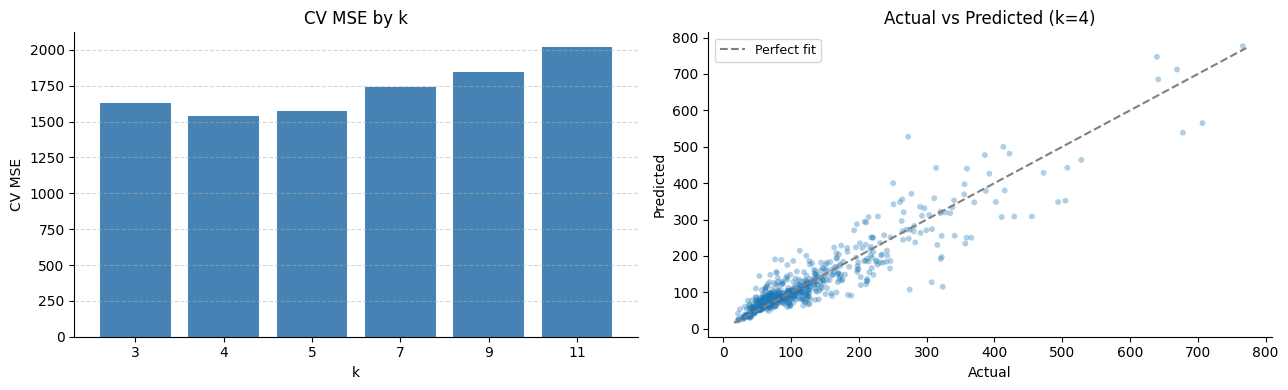

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv')
df.head()

X = df.drop(['rate_avg', 'Hotel_Occupancy_Percentage', 'Revenue_Per_Available_Room',
             'is_winter', 'is_spring', 'is_summer', 'is_fall', 'num_public_holidays',
             'non_resident_visitors', 'is_august', 'is_february', 'is_july', 'is_june',
             'is_november', 'is_september', 'listing_type_Private room in bungalow',
             'listing_type_Private room in home', 'listing_type_Private room in loft'], axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

neighbors_settings = [3, 4, 5, 7, 9, 11]

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)

    cv_results = cross_validate(knn, X_train_scaled, y_train, cv=5, scoring={
        'mse':  'neg_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'mape': 'neg_mean_absolute_percentage_error',
        'r2':   'r2'
    })
    cv_mse  = -cv_results['test_mse'].mean()
    cv_rmse = np.sqrt(cv_mse)
    cv_mae  = -cv_results['test_mae'].mean()
    cv_mape = -cv_results['test_mape'].mean()
    cv_r2   = cv_results['test_r2'].mean()

    records.append((n_neighbors, round(cv_r2, 4), round(cv_mse, 2), round(cv_rmse, 4), round(cv_mae, 2), round(cv_mape, 4)))
    preds[n_neighbors] = knn.fit(X_train_scaled, y_train).predict(X_test_scaled)

results_df = pd.DataFrame(records, columns=["k", "CV R²", "CV MSE", "CV RMSE", "CV MAE", "CV MAPE"]).set_index("k")
print(f"\nModel 4 — Optimal Lasso (α=0.035) Feature Selection - CV")
print(f"\n{'k':<6} {'CV R²':<10} {'CV MSE':<12} {'CV RMSE':<12} {'CV MAE':<12} {'CV MAPE':<10}")
print("-" * 62)
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['CV R²']:<10} {row['CV MSE']:<12} {row['CV RMSE']:<12} {row['CV MAE']:<12} {row['CV MAPE']:<10}")

best_k = results_df["CV MSE"].idxmin()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.bar([str(k) for k in results_df.index], results_df["CV MSE"], color="steelblue")
ax1.set_xlabel("k"); ax1.set_ylabel("CV MSE"); ax1.set_title("CV MSE by k")
ax1.grid(axis="y", linestyle="--", alpha=0.5); sns.despine(ax=ax1)
lims = [y_test.min() - 5, y_test.max() + 5]
ax2.plot(lims, lims, "--", color="gray", lw=1.5, label="Perfect fit")
ax2.scatter(y_test, preds[best_k], alpha=0.35, s=18, edgecolors="none")
ax2.set_xlabel("Actual"); ax2.set_ylabel("Predicted")
ax2.set_title(f"Actual vs Predicted (k={best_k})"); ax2.legend(fontsize=9)
sns.despine(ax=ax2); plt.tight_layout(); plt.show()

---
## Result Comparison - Section 1


In [10]:
import pandas as pd
import numpy as np

models = ['M1 No Scaling', 'M1 No Scaling (CV)',
          'M2 Scaled', 'M2 Scaled (CV)',
          'M4 Lasso α=0.035', 'M4 Lasso α=0.035 (CV)',
          'M3 Lasso α=1.0', 'M3 Lasso α=1.0 (CV)']

best_mse = [8001.59, 8615.61, 2978.95, 3415.10, 1499.27, 1535.90, 1069.31, 1230.98]

df_mse  = pd.DataFrame({'Model': models,
                        'Best k (MSE)':  [11,9,11,3,3,4,4,3],
                        'Best MSE':      best_mse})

df_rmse = pd.DataFrame({'Model': models,
                        'Best k (RMSE)': [11,9,11,3,3,4,4,3],
                        'Best RMSE':     [round(np.sqrt(v), 4) for v in best_mse]})

df_r2   = pd.DataFrame({'Model': models,
                        'Best k (R²)':  [9,9,11,4,3,4,4,3],
                        'Best R²':      [0.2484,0.2701,0.7201,0.7114,0.8591,0.8701,0.8995,0.8957]})

df_mae  = pd.DataFrame({'Model': models,
                        'Best k (MAE)': [11,11,11,9,3,4,4,3],
                        'Best MAE':     [55.91,57.70,37.64,37.24,23.64,24.88,19.87,20.76]})

df_mape = pd.DataFrame({'Model': models,
                        'Best k (MAPE)': [9,9,11,9,3,4,3,3],
                        'Best MAPE':     [0.52,0.5399,0.35,0.35,0.20,0.2258,0.17,0.1846]})

combined = (df_mse
            .merge(df_rmse, on='Model')
            .merge(df_r2,   on='Model')
            .merge(df_mae,  on='Model')
            .merge(df_mape, on='Model'))

combined = combined[['Model',
                     'Best k (MSE)',  'Best MSE',
                     'Best k (RMSE)', 'Best RMSE',
                     'Best k (R²)',   'Best R²',
                     'Best k (MAE)',  'Best MAE',
                     'Best k (MAPE)', 'Best MAPE']]

print(combined.to_string(index=False))

                Model  Best k (MSE)  Best MSE  Best k (RMSE)  Best RMSE  Best k (R²)  Best R²  Best k (MAE)  Best MAE  Best k (MAPE)  Best MAPE
        M1 No Scaling            11   8001.59             11    89.4516            9   0.2484            11     55.91              9     0.5200
   M1 No Scaling (CV)             9   8615.61              9    92.8203            9   0.2701            11     57.70              9     0.5399
            M2 Scaled            11   2978.95             11    54.5798           11   0.7201            11     37.64             11     0.3500
       M2 Scaled (CV)             3   3415.10              3    58.4389            4   0.7114             9     37.24              9     0.3500
     M4 Lasso α=0.035             3   1499.27              3    38.7204            3   0.8591             3     23.64              3     0.2000
M4 Lasso α=0.035 (CV)             4   1535.90              4    39.1906            4   0.8701             4     24.88              4    

---
### Key Insights from Models 1–4

From the results of Models 1–4, several important patterns emerge about how KNN performs on this dataset.

#### 1. Scaling has a major impact on performance

Scaling produced a significant improvement in model accuracy. Model 1 (no scaling) had an MSE of around **8000**, while Model 2 (scaled) reduced this to around **3000**.

This is because KNN relies entirely on **distance calculations**. When features are not scaled, variables with larger ranges dominate the distance metric, leading to poor neighbour selection and inaccurate predictions. Scaling ensures that all features contribute more equally, which results in more meaningful similarity comparisons between listings.

#### 2. Feature selection is the strongest driver of performance

Feature selection had the largest overall impact on model performance. Models 3 and 4, which used **Lasso-based feature reduction**, significantly outperformed Models 1 and 2 across all evaluation metrics.

- **Model 3 (Lasso α = 1.0, 39 features)** achieved the best results:
  - MSE: **1069**
  - R²: **0.8995**

  This indicates that the model explains approximately **90% of the variance** in Airbnb nightly price.

- **Model 4 (Lasso α = 0.035, 53 features)** performed slightly worse across all metrics.

This comparison suggests that the additional 14 features retained in Model 4 introduced **noise rather than useful information**. In KNN, having more features does not necessarily improve performance — in fact, it often degrades it.

A key takeaway is that for KNN, **feature noise is more harmful than feature loss**. The fact that a stronger Lasso penalty (α = 1.0) outperformed the “optimal” α = 0.035 indicates that aggressively removing weak predictors helped the model identify more meaningful neighbours.

This also suggests that a large portion of the original dataset consisted of **low-signal or noisy features**. Further increasing the Lasso penalty (i.e., using an even larger α) may have led to additional performance improvements by reducing noise even further.

#### 3. Cross-validation vs train/test results

The cross-validation and train/test results were very similar across all models, indicating that the models are **not overfitting**.

Cross-validation MSE values were slightly higher than train/test MSE values, which is expected. This is because cross-validation averages performance across multiple data splits, making it a more **reliable estimate of generalization performance**.

### Best Overall Model (from model 1-4)

The best-performing model is:

**Model 3 (Basic Train/Test, k = 4, Lasso α = 1.0)**

Final performance:
- **MSE:** 1069  
- **RMSE:** 32.70  
- **R²:** 0.8995  
- **MAE:** 19.87  

This means the model predicts Airbnb nightly price within approximately **$20 on average**, which is a strong result given the variability in listing prices (from the MAE)

---

## Section 2: KNN Workflow Using a Manually Shortened Feature List (60 selected features)


### Model 5: Manually Selected 60 Features with Manhattan Distance

This model uses a **manually shortened feature list** of **60 selected predictors** rather than Lasso-based feature elimination. The goal is to compare a more **domain-guided feature selection approach** against the Lasso-selected KNN model and evaluate whether a manually curated feature set can still produce strong predictive performance.

For **Model 5**, **Manhattan distance** was used instead of **Euclidean distance** because it can perform better in **high-dimensional datasets**, especially when many features are included.

In this project, even after reducing the dataset, the model still used **60 numerical features**. In higher-dimensional spaces, **Euclidean distance can become less effective** because the straight-line distance between points becomes less meaningful as dimensions increase. This is sometimes referred to as the **curse of dimensionality**.

**Manhattan distance** measures the distance between two points as the **sum of the absolute differences across each feature**, rather than the straight-line distance. This can make it:

- **less sensitive to large differences in a single feature,**
- **more stable when many features are present,** and
- often more appropriate when each feature contributes independently to similarity.

Mathematically:

- **Euclidean distance**:  
  $$
  d(x,y) = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}
  $$

- **Manhattan distance**:  
  $$
  d(x,y) = \sum_{i=1}^{n}|x_i - y_i|
  $$

Because this Airbnb dataset contains many standardized numerical features describing listings, location, host behaviour, and property characteristics, **Manhattan distance was chosen to reduce the effect of feature-by-feature outliers and to better handle the relatively large feature space**.

In practice, this made Manhattan distance a reasonable choice for comparing Airbnb listings across many attributes while keeping the distance calculation more stable and interpretable.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



## Load and inspect the cleaned dataset

We begin by loading the cleaned project dataset and checking its shape and first few rows. This matches the course emphasis on understanding the data before fitting a model.


In [12]:

# Load dataset
df = pd.read_csv("Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv")

print("Dataset shape:", df.shape)
print("First 5 rows:")
display(df.head())


Dataset shape: (3225, 71)
First 5 rows:


,rate_avg,photos_count,superhost,latitude,longitude,guests,bedrooms,beds,baths,min_nights,...,listing_type_Private room in loft,listing_type_Private room in rental unit,listing_type_Private room in townhouse,room_type_private_room,cancellation_policy_Flexible,cancellation_policy_Limited,cancellation_policy_Moderate,cancellation_policy_Strict,cancellation_policy_Super Strict 30 Days,avg_temp
0,36.3,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,-3.925
1,35.5,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,0.770
2,35.9,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,7.040
3,36.0,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,13.890
4,36.5,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,19.470


In [13]:

# Define target and selected predictors
target_col = "rate_avg"

features_to_drop = ['listing_type_Private room in bungalow', 'month', 'is_winter', 'is_spring', 'is_summer', 'is_fall', 'Hotel_Occupancy_Percentage', 'Average_Daily_Rate', 'Revenue_Per_Available_Room', 'listing_type_Private room in loft']

selected_features = [col for col in df.columns if col not in features_to_drop + [target_col]]

print("Number of selected predictors:", len(selected_features))
print(selected_features)

X = df[selected_features].copy()
y = df[target_col].copy()


Number of selected predictors: 60
['photos_count', 'superhost', 'latitude', 'longitude', 'guests', 'bedrooms', 'beds', 'baths', 'min_nights', 'cleaning_fee', 'extra_guest_fee', 'num_reviews', 'rating_overall', 'rating_accuracy', 'rating_checkin', 'rating_cleanliness', 'rating_communication', 'rating_location', 'rating_value', 'num_public_holidays', 'num_major_events', 'non_resident_visitors', 'is_april', 'is_august', 'is_february', 'is_july', 'is_june', 'is_march', 'is_may', 'is_november', 'is_october', 'is_september', 'has_free_parking', 'has_gym', 'has_pool', 'listing_type_Entire condo', 'listing_type_Entire condominium', 'listing_type_Entire guest suite', 'listing_type_Entire guesthouse', 'listing_type_Entire home', 'listing_type_Entire house', 'listing_type_Entire loft', 'listing_type_Entire place', 'listing_type_Entire rental unit', 'listing_type_Entire townhouse', 'listing_type_Private room', 'listing_type_Private room in condo', 'listing_type_Private room in cottage', 'listing_t

## Why these 60 features?

For our project, the goal is not just to run KNN mechanically. We want the distance between two listings to be **meaningful**. Since KNN is a **distance-based method**, too many irrelevant, redundant, or extremely sparse variables can make “nearest neighbors” less informative.

That is why we kept 60 features that are more directly connected to Airbnb pricing, including:
- **listing characteristics** such as guests, bedrooms, beds, baths, and minimum nights,
- **location variables** such as latitude and longitude,
- **amenities** such as free parking, gym, and pool,
- **review and rating information**,
- **listing and room type indicators**,
- **seasonal/month indicators** that capture time effects without over-duplicating them.

We removed 10 columns because they were less useful for a KNN pricing model:

1. **`listing_type_Private room in bungalow`**  
   This column is constant in the dataset, so it adds no information and cannot help distinguish neighbors.

2. **`listing_type_Private room in loft`**  
   This column is extremely sparse, so it is unlikely to help define stable neighborhoods in feature space.

3. **`month`**  
   We already have one-hot encoded month indicators (such as `is_april`, `is_may`, etc.), so keeping the raw `month` column would be redundant.

4. **`is_winter`, `is_spring`, `is_summer`, `is_fall`**  
   These seasonal indicators overlap with the month dummy variables. Because KNN uses distance directly, keeping both can overweight the same time-related effect.

5. **`Hotel_Occupancy_Percentage`, `Average_Daily_Rate`, `Revenue_Per_Available_Room`**  
   These are broader market indicators. They may contain some signal, but in this dataset they vary at a coarse monthly level and are weaker for defining listing-level similarity than the property, review, amenity, and location variables that we kept.

This feature selection step also ties back to course content on **data preparation, model selection, and generalization**. A simpler and more relevant feature set helps reduce noise, improve interpretability, and give KNN a better chance of identifying truly comparable listings.


In [14]:
dropped_feature_reasons = pd.DataFrame({
    "Dropped Feature": [
        "listing_type_Private room in bungalow",
        "listing_type_Private room in loft",
        "month",
        "is_winter",
        "is_spring",
        "is_summer",
        "is_fall",
        "Hotel_Occupancy_Percentage",
        "Average_Daily_Rate",
        "Revenue_Per_Available_Room"
    ],
    "Reason for Removal": [
        "Constant column (all zeros), so it adds no information for KNN.",
        "Extremely sparse category, so it is unlikely to define stable neighborhoods.",
        "Redundant with one-hot encoded month variables already in the dataset.",
        "Redundant with month dummy variables already capturing seasonal timing.",
        "Redundant with month dummy variables already capturing seasonal timing.",
        "Redundant with month dummy variables already capturing seasonal timing.",
        "Redundant with month dummy variables already capturing seasonal timing.",
        "Coarse market-level feature; weaker than listing-level similarity variables for KNN.",
        "Coarse market-level feature; weaker than listing-level similarity variables for KNN.",
        "Coarse market-level feature; weaker than listing-level similarity variables for KNN."
    ]
})

display(dropped_feature_reasons)


,Dropped Feature,Reason for Removal
0,listing_type_Private room in bungalow,"Constant column (all zeros), so it adds no inf..."
1,listing_type_Private room in loft,"Extremely sparse category, so it is unlikely t..."
2,month,Redundant with one-hot encoded month variables...
3,is_winter,Redundant with month dummy variables already c...
4,is_spring,Redundant with month dummy variables already c...
5,is_summer,Redundant with month dummy variables already c...
6,is_fall,Redundant with month dummy variables already c...
7,Hotel_Occupancy_Percentage,Coarse market-level feature; weaker than listi...
8,Average_Daily_Rate,Coarse market-level feature; weaker than listi...
9,Revenue_Per_Available_Room,Coarse market-level feature; weaker than listi...


In [15]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (2580, 60)
X_test shape: (645, 60)
y_train shape: (2580,)
y_test shape: (645,)


## KNN Modeling Approach

Following the workflow used in class, we first split the data into training and test sets, then define the model, fit it on the training data, and evaluate it on unseen data.

We use a **pipeline** so that:
1. the train/test split happens before model fitting,
2. feature scaling is learned only from the training data,
3. cross-validation stays clean,
4. data leakage is avoided.

This matters a lot for KNN because the model is entirely based on distance. If scaling were done on the full dataset before splitting, information from the test set could leak into the training process, which would make the results look better than they really are.


In [16]:
# Candidate values to test
k_values = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 25, 31]
weight_options = ["uniform", "distance"]
p_values = [1, 2]  # p=1 Manhattan, p=2 Euclidean

# Store all loop results here
loop_results = []

for weights in weight_options:
    for p in p_values:
        for k in k_values:
            knn_pipeline = Pipeline([
                ("scaler", StandardScaler()),
                ("knn", KNeighborsRegressor(
                    n_neighbors=k,
                    weights=weights,
                    p=p
                ))
            ])

            # Cross-validated RMSE on the training data
            cv_rmse_scores = -cross_val_score(
                knn_pipeline,
                X_train,
                y_train,
                cv=5,
                scoring="neg_root_mean_squared_error",
                n_jobs=-1
            )

            loop_results.append({
                "k": k,
                "weights": weights,
                "p": p,
                "distance_metric": "Manhattan" if p == 1 else "Euclidean",
                "cv_rmse_mean": cv_rmse_scores.mean(),
                "cv_rmse_std": cv_rmse_scores.std()
            })

results_df = pd.DataFrame(loop_results).sort_values(
    by="cv_rmse_mean", ascending=True
).reset_index(drop=True)

display(results_df.head(10))


,k,weights,p,distance_metric,cv_rmse_mean,cv_rmse_std
0,9,distance,1,Manhattan,37.325422,0.920993
1,7,distance,1,Manhattan,37.656201,0.620908
2,11,distance,1,Manhattan,37.889661,0.939512
3,5,distance,1,Manhattan,38.311846,1.097779
4,7,uniform,1,Manhattan,38.373752,0.443023
5,9,uniform,1,Manhattan,38.408622,0.934248
6,5,uniform,1,Manhattan,38.701282,1.014770
7,13,distance,1,Manhattan,38.773752,1.332207
8,11,uniform,1,Manhattan,39.466440,0.946136
9,15,distance,1,Manhattan,39.853743,1.734233


In [17]:
# Select the best parameter combination from the loop results
best_row = results_df.iloc[0]

best_k = int(best_row["k"])
best_weights = best_row["weights"]
best_p = int(best_row["p"])
best_distance = best_row["distance_metric"]

print("Best parameters found from manual tuning loop:")
print(f"k = {best_k}")
print(f"weights = {best_weights}")
print(f"distance metric = {best_distance} (p = {best_p})")

Best parameters found from manual tuning loop:
k = 9
weights = distance
distance metric = Manhattan (p = 1)


In [18]:
# Fit the final KNN model using the best parameters found above
best_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(
        n_neighbors=best_k,
        weights=best_weights,
        p=best_p
    ))
])

best_knn.fit(X_train, y_train)
y_pred = best_knn.predict(X_test)

# Evaluate on the held-out test set
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R^2:", r2)


Test MSE: 1306.5696546477802
Test RMSE: 36.14650266136103
Test MAE: 22.79847370766862
Test R^2: 0.8772143548873329


In [19]:
# Cross-validated RMSE scores for the final selected model on the training data
final_cv_rmse_scores = -cross_val_score(
    best_knn,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

final_cv_mse_scores = final_cv_rmse_scores ** 2

print("Fold RMSE values:", final_cv_rmse_scores)
print("Mean CV RMSE:", final_cv_rmse_scores.mean())
print("Std CV RMSE:", final_cv_rmse_scores.std())
print("Mean CV MSE:", final_cv_mse_scores.mean())


Fold RMSE values: [36.45772083 38.11612043 37.68081525 36.0247675  38.34768586]
Mean CV RMSE: 37.32542197540808
Std CV RMSE: 0.9209928562209392
Mean CV MSE: 1394.035353483486


In [20]:
# Summary of KNN regression results for the project dataset
results_summary = pd.DataFrame({
    "Metric": ["Best CV RMSE", "Mean CV MSE", "Test MSE", "Test RMSE", "Test MAE", "Test R^2"],
    "Value": [
        results_df.iloc[0]["cv_rmse_mean"],
        final_cv_mse_scores.mean(),
        mse,
        rmse,
        mae,
        r2
    ]
})

display(results_summary)


,Metric,Value
0,Best CV RMSE,37.325422
1,Mean CV MSE,1394.035353
2,Test MSE,1306.569655
3,Test RMSE,36.146503
4,Test MAE,22.798474
5,Test R^2,0.877214


## Model diagnostics and interpretation

The plots below help us interpret how the tuned KNN model behaves.

- The **actual vs. predicted** plot shows how closely the model’s predictions match the true average prices on the held-out test set.  
- The **CV RMSE vs. k** plot shows how model performance changes as the number of neighbors changes under different weighting and distance settings.

Together, these plots connect back to the course discussion of choosing **k** carefully: small values can be sensitive to noise, while large values may smooth the predictions too much by averaging over listings that are not truly similar.


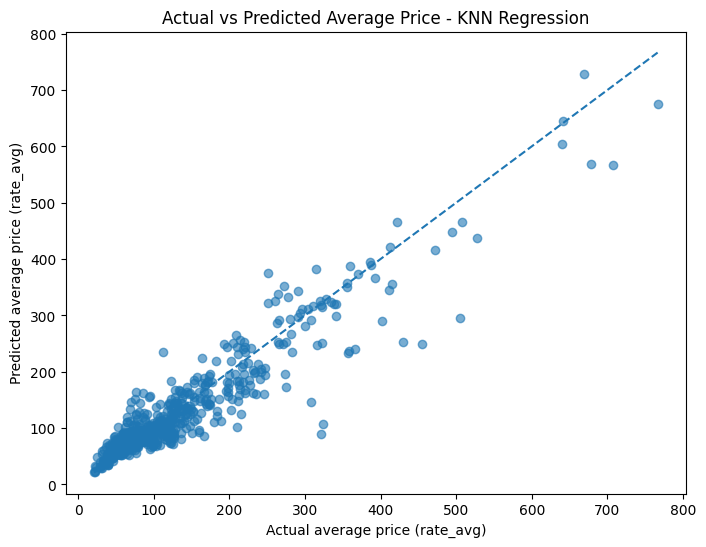

In [21]:

# Plot actual vs predicted
# using the best K value found in loop (cross-validation)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.xlabel("Actual average price (rate_avg)")
plt.ylabel("Predicted average price (rate_avg)")
plt.title("Actual vs Predicted Average Price - KNN Regression")
plt.show()


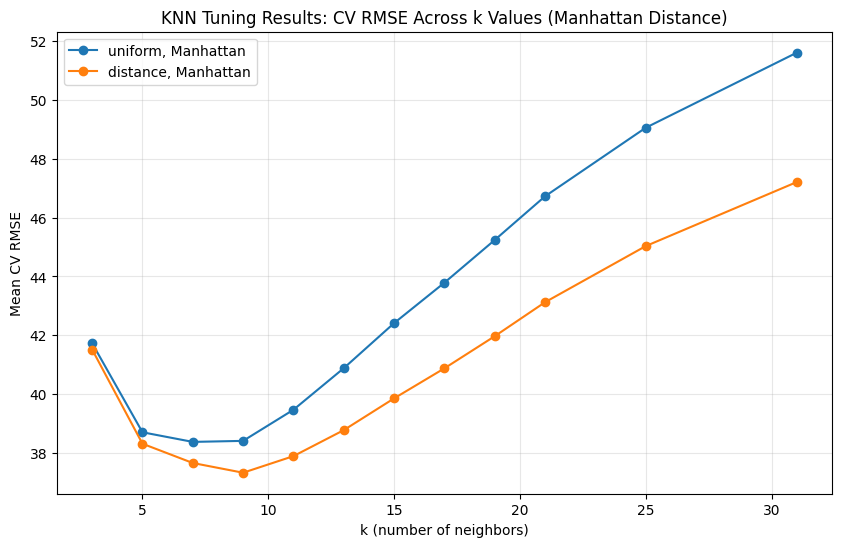

In [22]:
# Plot CV RMSE vs k for Manhattan distance only
plt.figure(figsize=(10, 6))

for weights in weight_options:
    subset = results_df[
        (results_df["weights"] == weights) &
        (results_df["p"] == 1)
    ].sort_values("k")

    label = f"{weights}, Manhattan"
    plt.plot(subset["k"], subset["cv_rmse_mean"], marker="o", label=label)

plt.xlabel("k (number of neighbors)")
plt.ylabel("Mean CV RMSE")
plt.title("KNN Tuning Results: CV RMSE Across k Values (Manhattan Distance)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Final Takeaway for Model 5

Model 5 applies KNN regression in a way that is consistent with core **MSE 446 machine learning principles**, including:
- purposeful feature selection,
- proper train/test separation,
- feature scaling for a distance-based model,
- cross-validation for hyperparameter tuning, and
- final evaluation on unseen test data.

The results show that KNN can perform well for Airbnb price prediction when listings are represented using a carefully selected set of relevant numerical features. This supports the idea that Airbnb pricing is partly **similarity-based**, meaning that listings with similar characteristics tend to have similar prices.

Although Model 5 did not outperform the strongest KNN variant overall, it still produced solid predictive results and served as a valuable comparison model. Its main strength is that it uses a **manually selected and interpretable feature set**, making it easier to justify and explain than a more automated feature selection approach.

Overall, Model 5 shows that KNN can be an effective method for this prediction task, but that performance depends heavily on **feature selection, scaling, and distance metric choice**.

---
## Section 3: Final Comparison and Recommendation

This section compares the two **KNN feature selection approaches** used in this project:

- **Model 3**, which used **Lasso-based feature selection**
- **Model 5**, which used a **manually selected 60-feature subset**

The goal of this comparison is to evaluate whether a **data-driven feature reduction method** or a **domain-guided manual feature selection method** produces stronger KNN performance for predicting Airbnb price.

### Performance comparison

- **Model 3:** Lasso feature selection with **α = 1.0** and **39 features**
  - Test MSE: **1069.31**
  - Test RMSE: **32.70**
  - Test R²: **0.8995**
  - Test MAE: **19.87**

- **Model 5:** manually selected **60 features**, with **Manhattan distance** and **distance weighting**
  - Test MSE: **1306.57**
  - Test RMSE: **36.15**
  - Test R²: **0.8772**
  - Test MAE: **22.80**

### Which approach performed better?

Based on the evaluation metrics, **Model 3 performed better overall**. It achieved the **lowest error values** and the **highest R²**, meaning it predicted Airbnb prices more accurately on unseen test data.

This suggests that for KNN, **removing noisy or weak predictors is extremely important**. Since KNN relies entirely on **distance between observations**, irrelevant variables can distort similarity calculations and make it harder for the model to identify truly comparable listings.

### Why is Model 3 better?

The stronger performance of Model 3 supports an important machine learning takeaway:  
for **distance-based models like KNN**, **feature quality often matters more than feature quantity**.

Model 3 retained only **39 Lasso-selected features**, while Model 5 used **60 manually selected features**. Although Model 5 still performed well, the extra features likely introduced additional noise into the distance calculations. This would reduce the model’s ability to identify the most relevant nearest neighbours.

This aligns with the earlier KNN results from Models 1–4, which showed that:

1. **Scaling significantly improves KNN performance** because all features must contribute fairly to distance calculations.
2. **Feature selection is a major driver of performance**, since too many weak or irrelevant variables reduce the quality of neighbour matching.
3. **Cross-validation and test results were similar**, suggesting the KNN models were reasonably stable and not strongly overfit.

### Why is Model 5 still useful?

Although **Model 5 did not outperform Model 3**, it still serves as a strong comparison model.

Its main advantage is **interpretability**. Because the features were selected manually, the model is easier to explain and justify from a **domain knowledge** perspective. It also demonstrates that KNN can still perform well when built using a carefully reduced feature set without relying entirely on automated feature selection.

Additionally, Model 5 introduced **Manhattan distance** rather than Euclidean distance, which was a reasonable choice given the relatively high-dimensional feature space. This makes Model 5 a useful methodological comparison rather than just a weaker duplicate of the Lasso-based approach.

### Final recommendation

Overall, **Model 3 is the strongest KNN model in the project**.

It provides the best balance of:
- **low prediction error,**
- **strong explanatory power (R²),** and
- **effective feature reduction for a distance-based model.**

However, **Model 5 is still valuable to include** because it shows that a **manually selected, domain-guided KNN approach** can also perform competitively, even if it does not match the strongest Lasso-based model.

### Best Overall KNN Model

The **best overall KNN model** is:

**Model 3 (Basic Train/Test with Lasso α = 1.0 and 39 features)**

Final performance:
- **MSE:** 1069.31  
- **RMSE:** 32.70  
- **R²:** 0.8995  
- **MAE:** 19.87  

This means the model predicts Airbnb nightly price with an average absolute error of approximately **$20**, which is a strong result for a KNN regression model.